# Remote Sensing Image Captioning: ViT-GPT2

Notebook ini mengimplementasikan pendekatan **vision-language model** dengan menggabungkan **ViT-B/16 (HuggingFace)** sebagai _visual encoder_ dan **GPT-2** sebagai _autoregressive caption generator_.

Arsitektur ini menggunakan GPT-2 sebagai _decoder_ berbasis _transformer_. _Visual encoder_ yang digunakan adalah ViT generik dengan mekanisme **multi-scale feature extraction** dan **spatial-aware attention pooling** yang lebih _sophisticated_.

| Komponen | Detail |
|---|---|
| **Dataset** | [Satellite Image Caption Generation](https://www.kaggle.com/datasets/tomtillo/satellite-image-caption-generation) |
| **Split** | Train: 33.305 / Valid: 4.370 / Test: 5.063 captions |
| **Framework** | PyTorch |
| **Visual Encoder** | ViT-B/16 (`google/vit-base-patch16-224`, frozen) |
| **Feature Fusion** | MultiScaleFeatureExtractor (layer 6, 9, 12) + SpatialAwareAttentionPooling |
| **Decoder** | GPT-2 (fine-tuned) |
| **Total Params** | 222.1M (Trainable: 135.7M) |
| **Metrics** | BLEU-1~4, METEOR, ROUGE-L, CIDEr |

## 1. Install Dependencies

Menginstall library yang dibutuhkan:
- `pycocoevalcap` — library evaluasi caption standar (BLEU, METEOR, ROUGE-L, CIDEr)
- `transformers` — untuk load ViT dan GPT-2 model dari HuggingFace

In [ ]:
!pip install git+https://github.com/salaniz/pycocoevalcap.git

In [ ]:
!pip install transformers

## 2. Import Library

In [ ]:
import os
import re
import json
import random
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from transformers import (
    ViTModel,
    ViTImageProcessor,
    GPT2LMHeadModel,
    GPT2Tokenizer,
    get_cosine_schedule_with_warmup,
)

from pycocoevalcap.bleu.bleu import Bleu
from pycocoevalcap.meteor.meteor import Meteor
from pycocoevalcap.rouge.rouge import Rouge
from pycocoevalcap.cider.cider import Cider

warnings.filterwarnings('ignore')

2025-11-30 16:00:58.942720: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764518459.153916      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764518459.215920      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 3. Dataset Preparation

Load dataset dari Kaggle Satellite Image Caption Generation. Dataset terdiri dari 3 split (train/valid/test) dalam format CSV.

In [5]:
image_path = '/kaggle/input/satellite-image-caption-generation/'

train_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/train.csv")
train_data['filepath'] = image_path + train_data['filepath']

valid_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/valid.csv")
valid_data['filepath'] = image_path + valid_data['filepath']

test_data = pd.read_csv("/kaggle/input/satellite-image-caption-generation/test.csv")
test_data['filepath'] = image_path + test_data['filepath']

## 4. Text Preprocessing

Fungsi `splitting_dataset` memproses setiap baris dataset dengan cara:
1. Memisahkan _multiple captions_ per gambar menjadi baris terpisah (1 baris = 1 gambar + 1 caption)
2. Membersihkan karakter khusus dan _whitespace_ berlebih
3. Menghapus duplikat caption (_case-insensitive_) per gambar
4. Memfilter caption yang terlalu pendek (< 5 karakter)

In [6]:
def splitting_dataset(df):
    processed_data = []
    
    for idx, row in df.iterrows():
        filepath = row['filepath']
        captions_str = row['captions']
        
        captions = captions_str.strip("[]").split("'\n '")
        captions = [c.strip("'").strip() for c in captions]
        
        seen_captions = set()
        for caption in captions:
            # Clean caption
            caption = caption.replace('\n', ' ')
            caption = ' '.join(caption.split())
            caption = caption.rstrip('.')
            
            # Skip duplicates (case-insensitive)
            caption_lower = caption.lower()
            if caption_lower not in seen_captions and len(caption) > 5:
                seen_captions.add(caption_lower)
                processed_data.append({
                    'image_path': filepath,
                    'caption': caption
                })
    
    return pd.DataFrame(processed_data)

In [7]:
train_df = splitting_dataset(train_data)
valid_df = splitting_dataset(valid_data)
test_df = splitting_dataset(test_data)

In [8]:
print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(valid_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 33305
Val samples: 4370
Test samples: 5063


## 5. Arsitektur Model

Arsitektur terdiri dari 4 komponen utama yang disusun secara berurutan.

- **ViT-B/16** digunakan sebagai visual _encoder_ dalam _mode frozen_ (`output_hidden_states=True`). _Hidden states_ dari layer ke-6, 9, dan 12 diekstrak untuk menangkap fitur dari berbagai level abstraksi.

- **MultiScaleFeatureExtractor** menggabungkan ketiga _hidden states_ tersebut menggunakan _learnable weighted sum_, lalu diproyeksikan melalui Linear(768→768) → GELU → LayerNorm menghasilkan 49 _patch tokens_ berdimensi 768.

- **SpatialAwareAttentionPooling** memproses _patch tokens_ dengan _cross-attention_ antara _learnable query tokens_ dan _patch features_, dilanjutkan _self-attention_ dan FFN. Komponen ini dilengkapi **SpatialPositionalEncoding** berupa 2D _positional encoding_ (row + col _embedding_ pada grid 7×7) untuk mempertahankan informasi spasial _patch_ gambar. Output berupa 49 _visual tokens_ berdimensi 768.

- _Visual tokens_ tersebut digabungkan dengan _text embeddings_ GPT-2, lalu dimasukkan ke **GPT-2 LM Head** untuk menghasilkan caption secara autoregressive.

In [9]:
class SpatialPositionalEncoding(nn.Module):
    def __init__(self, embed_dim, grid_size=7):
        super().__init__()
        self.grid_size = grid_size
        self.row_embed = nn.Parameter(torch.randn(grid_size, embed_dim // 2) * 0.02)
        self.col_embed = nn.Parameter(torch.randn(grid_size, embed_dim // 2) * 0.02)
    
    def forward(self, batch_size, device):
        row_pos = self.row_embed.unsqueeze(1).repeat(1, self.grid_size, 1)
        col_pos = self.col_embed.unsqueeze(0).repeat(self.grid_size, 1, 1)
        spatial_pos = torch.cat([row_pos, col_pos], dim=-1)
        spatial_pos = spatial_pos.view(1, self.grid_size * self.grid_size, -1)
        spatial_pos = spatial_pos.expand(batch_size, -1, -1).to(device)
        return spatial_pos

In [10]:
class MultiScaleFeatureExtractor(nn.Module):
    def __init__(self, vit_dim, output_dim, layer_indices=[6, 9, 12]):
        super().__init__()
        self.layer_indices = layer_indices
        self.num_layers = len(layer_indices)
        self.layer_weights = nn.Parameter(torch.ones(self.num_layers) / self.num_layers)
        self.layer_norms = nn.ModuleList([nn.LayerNorm(vit_dim) for _ in layer_indices])
        self.fusion = nn.Sequential(
            nn.Linear(vit_dim, output_dim),
            nn.GELU(),
            nn.LayerNorm(output_dim)
        )
    
    def forward(self, hidden_states_list):
        weights = F.softmax(self.layer_weights, dim=0)
        fused = None
        for i, (hidden_state, layer_norm) in enumerate(zip(hidden_states_list, self.layer_norms)):
            normed = layer_norm(hidden_state)
            if fused is None:
                fused = weights[i] * normed
            else:
                fused = fused + weights[i] * normed
        output = self.fusion(fused)
        return output

In [11]:
class SpatialAwareAttentionPooling(nn.Module):
    def __init__(self, embed_dim, num_heads=8, num_queries=49, dropout=0.1):
        super().__init__()
        self.num_queries = num_queries
        self.grid_size = int(math.sqrt(num_queries))
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, embed_dim) * 0.02)
        self.spatial_pos = SpatialPositionalEncoding(embed_dim, self.grid_size)
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.self_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim),
            nn.Dropout(dropout)
        )
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.norm3 = nn.LayerNorm(embed_dim)
    
    def forward(self, visual_features):
        batch_size = visual_features.shape[0]
        device = visual_features.device
        queries = self.query_tokens.expand(batch_size, -1, -1)
        spatial_pos = self.spatial_pos(batch_size, device)
        queries = queries + spatial_pos
        attended, cross_attn_weights = self.cross_attn(
            queries, visual_features, visual_features
        )
        queries = self.norm1(queries + attended)
        self_attended, _ = self.self_attn(queries, queries, queries)
        queries = self.norm2(queries + self_attended)
        output = self.norm3(queries + self.ffn(queries))
        return output, cross_attn_weights

In [12]:
class ViTGPT2(nn.Module):
    def __init__(
        self,
        vit_model='google/vit-base-patch16-224',
        gpt2_model='gpt2',
        num_image_tokens=49,
        freeze_vision=True,
        freeze_lm_initial_epochs=0,
        dropout=0.15,
        multi_scale_layers=[6, 9, 12]
    ):
        super().__init__()
        self.vit = ViTModel.from_pretrained(vit_model, output_hidden_states=True)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_model)
        self.vit_dim = self.vit.config.hidden_size
        self.gpt2_dim = self.gpt2.config.n_embd
        self.num_image_tokens = num_image_tokens
        self.multi_scale_layers = multi_scale_layers
        self.multi_scale_extractor = MultiScaleFeatureExtractor(
            vit_dim=self.vit_dim,
            output_dim=self.vit_dim,
            layer_indices=multi_scale_layers
        )
        self.spatial_attention = SpatialAwareAttentionPooling(
            embed_dim=self.vit_dim,
            num_heads=12,
            num_queries=num_image_tokens,
            dropout=dropout
        )
        self.visual_projection = nn.Sequential(
            nn.Linear(self.vit_dim, self.gpt2_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(self.gpt2_dim, self.gpt2_dim),
            nn.LayerNorm(self.gpt2_dim)
        )
        self._init_weights()
        self.freeze_vision = freeze_vision
        self.freeze_lm_initial_epochs = freeze_lm_initial_epochs
        self.current_epoch = 0
        if freeze_vision:
            self._freeze_vision_model()
    
    def _init_weights(self):
        for module in self.visual_projection.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.01)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
        for module in self.multi_scale_extractor.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.01)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
    
    def _freeze_vision_model(self):
        for param in self.vit.parameters():
            param.requires_grad = False
    
    def _unfreeze_vision_model(self):
        for param in self.vit.parameters():
            param.requires_grad = True
    
    def _freeze_lm_model(self):
        for param in self.gpt2.parameters():
            param.requires_grad = False
    
    def _unfreeze_lm_model(self):
        for param in self.gpt2.parameters():
            param.requires_grad = True
    
    def update_freeze_status(self, epoch):
        self.current_epoch = epoch
        if epoch == self.freeze_lm_initial_epochs and self.freeze_lm_initial_epochs > 0:
            print(f"Epoch {epoch}: Unfreezing GPT2")
            self._unfreeze_lm_model()
    
    def encode_image(self, pixel_values):
        if self.freeze_vision:
            with torch.no_grad():
                vit_outputs = self.vit(pixel_values, output_hidden_states=True)
                hidden_states = vit_outputs.hidden_states
                selected_features = [hidden_states[i].detach() for i in self.multi_scale_layers]
        else:
            vit_outputs = self.vit(pixel_values, output_hidden_states=True)
            hidden_states = vit_outputs.hidden_states
            selected_features = [hidden_states[i] for i in self.multi_scale_layers]
        multi_scale_features = self.multi_scale_extractor(selected_features)
        spatial_features, attn_weights = self.spatial_attention(multi_scale_features)
        visual_embeds = self.visual_projection(spatial_features)
        return visual_embeds
    
    def forward(
        self,
        pixel_values,
        input_ids=None,
        attention_mask=None,
        labels=None
    ):
        batch_size = pixel_values.shape[0]
        image_embeds = self.encode_image(pixel_values)
        if input_ids is not None:
            text_embeds = self.gpt2.transformer.wte(input_ids)
            inputs_embeds = torch.cat([image_embeds, text_embeds], dim=1)
            image_attn = torch.ones(
                batch_size, self.num_image_tokens,
                dtype=attention_mask.dtype,
                device=attention_mask.device
            )
            attention_mask = torch.cat([image_attn, attention_mask], dim=1)
            if labels is not None:
                image_labels = torch.full(
                    (batch_size, self.num_image_tokens),
                    -100,
                    dtype=labels.dtype,
                    device=labels.device
                )
                labels = torch.cat([image_labels, labels], dim=1)
            outputs = self.gpt2(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                labels=labels
            )
            return outputs
        else:
            return image_embeds
    
    def generate_caption(
        self,
        pixel_values,
        tokenizer,
        max_length=50,
        min_length=8,
        temperature=0.7,
        top_p=0.9,
        top_k=50,
        repetition_penalty=1.2,
        num_beams=5,
        no_repeat_ngram_size=3,
        device='cuda'
    ):
        self.eval()
        with torch.no_grad():
            image_embeds = self.encode_image(pixel_values)
            batch_size = image_embeds.shape[0]
            bos_token_id = tokenizer.bos_token_id
            bos_embeds = self.gpt2.transformer.wte(
                torch.tensor([[bos_token_id]], device=device).expand(batch_size, -1)
            )
            inputs_embeds = torch.cat([image_embeds, bos_embeds], dim=1)
            attention_mask = torch.ones(
                (batch_size, self.num_image_tokens + 1),
                device=device
            )
            outputs = self.gpt2.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                max_new_tokens=max_length,
                min_new_tokens=min_length,
                temperature=temperature,
                do_sample=False,
                num_beams=num_beams,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
                bos_token_id=tokenizer.bos_token_id,
                early_stopping=True,
                length_penalty=1.0,
                num_return_sequences=1
            )
            captions = []
            for ids in outputs:
                caption = tokenizer.decode(ids, skip_special_tokens=True)
                caption = caption.strip()
                if caption and caption[-1] not in '.!?':
                    caption += '.'
                captions.append(caption)
            return captions[0] if len(captions) == 1 else captions

## 6. PyTorch Dataset & DataLoader

Dua Dataset class diimplementasikan:
- **`RSICDataset`**: Untuk training → load gambar, terapkan augmentasi opsional (flip horizontal/vertikal, rotasi 90°/180°), dan tokenisasi caption dengan `<|startoftext|>` / `<|endoftext|>`
- **`RSICEvalDataset`**: Untuk evaluasi → group semua captions per gambar untuk evaluasi yang efisien
- **`collate_fn`**: Custom collate untuk menangani batch dengan padding yang konsisten

In [13]:
class RSICDataset(Dataset):
    def __init__(
        self,
        dataframe,
        feature_extractor,
        tokenizer,
        max_length=60,
        augment=False
    ):
        self.df = dataframe.reset_index(drop=True)
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.augment = augment
        
        if augment:
            self.geometric_transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=[90, 90])
                ], p=0.25),
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=[180, 180])
                ], p=0.25),
                transforms.RandomApply([
                    transforms.RandomRotation(degrees=[270, 270])
                ], p=0.25),
            ])
            self.color_transform = transforms.Compose([
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2,
                    saturation=0.15,
                    hue=0.05
                ),
                transforms.RandomApply([
                    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))
                ], p=0.1),
            ])
            self.spatial_transform = transforms.RandomApply([
                transforms.RandomResizedCrop(
                    224,
                    scale=(0.9, 1.0),
                    ratio=(0.95, 1.05)
                )
            ], p=0.3)
        else:
            self.geometric_transform = None
            self.color_transform = None
            self.spatial_transform = None
    
    def __len__(self):
        return len(self.df)
    
    def _apply_augmentation(self, image):
        if self.geometric_transform:
            image = self.geometric_transform(image)
        if self.spatial_transform:
            image = self.spatial_transform(image)
        if self.color_transform:
            image = self.color_transform(image)
        return image
    
    def _clean_caption(self, caption):
        caption = caption.strip().lower()
        caption = ' '.join(caption.split())
        if caption and caption[-1] not in '.!?':
            caption += '.'
        return caption
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = row['image_path']
        
        try:
            image = Image.open(image_path).convert('RGB')
            if self.augment:
                image = self._apply_augmentation(image)
            pixel_values = self.feature_extractor(image, return_tensors='pt').pixel_values[0]
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            pixel_values = torch.zeros((3, 224, 224))
        
        caption = self._clean_caption(row['caption'])
        caption_with_tokens = f"{self.tokenizer.bos_token}{caption}{self.tokenizer.eos_token}"
        
        encoding = self.tokenizer(
            caption_with_tokens,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        input_ids = encoding.input_ids[0]
        attention_mask = encoding.attention_mask[0]
        
        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        labels[0] = -100
        
        return {
            'pixel_values': pixel_values,
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

In [14]:
class RSICEvalDataset(Dataset):
    def __init__(
        self,
        dataframe,
        feature_extractor,
        tokenizer,
        max_length=60
    ):
        self.feature_extractor = feature_extractor
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        self.image_to_captions = {}
        for _, row in dataframe.iterrows():
            img_path = row['image_path']
            caption = row['caption'].strip().lower()
            if img_path not in self.image_to_captions:
                self.image_to_captions[img_path] = []
            self.image_to_captions[img_path].append(caption)
        
        self.image_paths = list(self.image_to_captions.keys())
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        captions = self.image_to_captions[image_path]
        
        try:
            image = Image.open(image_path).convert('RGB')
            pixel_values = self.feature_extractor(image, return_tensors='pt').pixel_values[0]
        except Exception as e:
            print(f"Error loading image {image_path}: {e}")
            pixel_values = torch.zeros((3, 224, 224))
        
        return {
            'pixel_values': pixel_values,
            'image_path': image_path,
            'captions': captions
        }

In [15]:
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    image_paths = [item['image_path'] for item in batch]
    captions = [item['captions'] for item in batch]
    
    return {
        'pixel_values': pixel_values,
        'image_paths': image_paths,
        'captions': captions
    }

## 7. Trainer Class

Class `Trainer` mengenkapsulasi seluruh training loop dengan fitur:
- **Mixed Precision Training** (AMP) untuk efisiensi memori GPU
- **Gradient Accumulation** untuk simulasi batch size lebih besar
- **Gradient Clipping** (max norm 1.0) untuk stabilitas training
- **Cosine LR Schedule** dengan warmup
- **Early Stopping** (patience=7) dengan automatic checkpoint saving
- **Progressive ViT unfreezing** — ViT di-freeze di awal, lalu di-unfreeze setelah beberapa epoch

In [16]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        tokenizer,
        feature_extractor,
        learning_rate=5e-5,
        warmup_ratio=0.1,
        weight_decay=0.01,
        num_epochs=20,
        gradient_accumulation_steps=1,
        device='cuda'
    ):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.tokenizer = tokenizer
        self.feature_extractor = feature_extractor
        self.device = device
        self.num_epochs = num_epochs
        self.gradient_accumulation_steps = gradient_accumulation_steps
        
        self.history = {
            'train_loss': [],
            'train_perplexity': [],
            'val_loss': [],
            'val_perplexity': [],
            'learning_rate': [],
            'epochs': []
        }
        
        vision_params = []
        multi_scale_params = []
        spatial_attention_params = []
        projection_params = []
        lm_params = []
        
        for name, param in model.named_parameters():
            if param.requires_grad:
                if 'vit' in name:
                    vision_params.append(param)
                elif 'multi_scale' in name:
                    multi_scale_params.append(param)
                elif 'spatial_attention' in name:
                    spatial_attention_params.append(param)
                elif 'visual_projection' in name:
                    projection_params.append(param)
                else:
                    lm_params.append(param)
        
        optimizer_groups = []
        
        if vision_params:
            optimizer_groups.append({
                'params': vision_params,
                'lr': learning_rate * 0.01,
                'weight_decay': 0.0,
                'name': 'vision'
            })
        
        if multi_scale_params:
            optimizer_groups.append({
                'params': multi_scale_params,
                'lr': learning_rate * 2,
                'weight_decay': weight_decay,
                'name': 'multi_scale'
            })
        
        if spatial_attention_params:
            optimizer_groups.append({
                'params': spatial_attention_params,
                'lr': learning_rate * 3,
                'weight_decay': weight_decay,
                'name': 'spatial_attention'
            })
        
        if projection_params:
            optimizer_groups.append({
                'params': projection_params,
                'lr': learning_rate * 2,
                'weight_decay': weight_decay,
                'name': 'projection'
            })
        
        if lm_params:
            optimizer_groups.append({
                'params': lm_params,
                'lr': learning_rate,
                'weight_decay': weight_decay,
                'name': 'lm'
            })
        
        self.optimizer = AdamW([
            {k: v for k, v in g.items() if k != 'name'} 
            for g in optimizer_groups
        ])
        
        total_steps = (len(train_loader) // gradient_accumulation_steps) * num_epochs
        warmup_steps = int(total_steps * warmup_ratio)
        
        self.scheduler = get_cosine_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )
        
        self.best_val_loss = float('inf')
        self.patience_counter = 0
        
    def train_epoch(self, epoch):
        self.model.train()
        self.model.update_freeze_status(epoch)
        
        total_loss = 0
        total_tokens = 0
        self.optimizer.zero_grad()
        
        progress = tqdm(self.train_loader, desc=f'Epoch {epoch}')
        
        for batch_idx, batch in enumerate(progress):
            pixel_values = batch['pixel_values'].to(self.device)
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)
            
            outputs = self.model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss / self.gradient_accumulation_steps
            loss.backward()
            
            if (batch_idx + 1) % self.gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()
                self.scheduler.step()
                self.optimizer.zero_grad()
            
            num_tokens = (labels != -100).sum().item()
            total_loss += outputs.loss.item() * num_tokens
            total_tokens += num_tokens
            
            current_loss = total_loss / total_tokens if total_tokens > 0 else 0
            progress.set_postfix({
                'loss': f'{outputs.loss.item():.4f}',
                'avg': f'{current_loss:.4f}',
                'ppl': f'{np.exp(min(current_loss, 10)):.2f}',
                'lr': f'{self.scheduler.get_last_lr()[0]:.2e}'
            })
        
        avg_loss = total_loss / total_tokens if total_tokens > 0 else 0
        return avg_loss
    
    def validate(self):
        self.model.eval()
        total_loss = 0
        total_tokens = 0
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc='Validation'):
                pixel_values = batch['pixel_values'].to(self.device)
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(
                    pixel_values=pixel_values,
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                
                num_tokens = (labels != -100).sum().item()
                total_loss += outputs.loss.item() * num_tokens
                total_tokens += num_tokens
        
        avg_loss = total_loss / total_tokens if total_tokens > 0 else 0
        return avg_loss
    
    def save_checkpoint(self, save_path, epoch, train_loss, val_loss, is_best=False):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'history': self.history,
            'best_val_loss': self.best_val_loss
        }
        torch.save(checkpoint, save_path)
        if is_best:
            print(f"Saved best model (val_loss: {val_loss:.4f})")
    
    def save_history(self, save_dir):
        history_path = os.path.join(save_dir, 'training_history.json')
        with open(history_path, 'w') as f:
            json.dump(self.history, f, indent=4)
    
    def train(self, num_epochs=None, save_dir='./checkpoints', patience=7):
        if num_epochs is None:
            num_epochs = self.num_epochs
        
        os.makedirs(save_dir, exist_ok=True)
        
        for epoch in range(1, num_epochs + 1):
            print(f"Epoch {epoch}/{num_epochs}")
            
            train_loss = self.train_epoch(epoch)
            val_loss = self.validate()
            
            train_ppl = np.exp(min(train_loss, 10))
            val_ppl = np.exp(min(val_loss, 10))
            
            self.history['epochs'].append(epoch)
            self.history['train_loss'].append(float(train_loss))
            self.history['train_perplexity'].append(float(train_ppl))
            self.history['val_loss'].append(float(val_loss))
            self.history['val_perplexity'].append(float(val_ppl))
            self.history['learning_rate'].append(float(self.scheduler.get_last_lr()[0]))
            
            print(f"Train Loss: {train_loss:.4f} | Train PPL: {train_ppl:.2f}")
            print(f"Val Loss:   {val_loss:.4f} | Val PPL:   {val_ppl:.2f}")
            
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.patience_counter = 0
                save_path = os.path.join(save_dir, 'vit_gpt2_rsic_best_model.pt')
                self.save_checkpoint(save_path, epoch, train_loss, val_loss, is_best=True)
            else:
                self.patience_counter += 1
                print(f"No improvement. Patience: {self.patience_counter}/{patience}")
            
            if self.patience_counter >= patience:
                print(f"\nEarly stopping triggered after {epoch} epochs")
                break
            
            self.save_history(save_dir)
        
        self.save_history(save_dir)

        print(f"Best Validation Loss: {self.best_val_loss:.4f}")
        
        return self.history
    
    def load_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.history = checkpoint.get('history', self.history)
        self.best_val_loss = checkpoint.get('best_val_loss', float('inf'))
        print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
        return checkpoint['epoch']

## 8. Training

Setup seed, inisialisasi tokenizer, feature extractor, dataset, dataloader, model, dan trainer — lalu jalankan training loop.

Konfigurasi training:
- **Epochs**: 20 (dengan early stopping patience=7)
- **Learning Rate**: 5e-5 dengan cosine schedule + warmup
- **Batch Size**: 16
- **Optimizer**: AdamW dengan weight decay 0.01
- **Augmentasi**: Random flip & rotasi pada training set

Model berhenti di epoch 10 karena early stopping. **Best model: epoch 3**, val_loss: **1.8538**.

In [14]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def main():
    set_seed(42)
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
    
    special_tokens_dict = {
        'bos_token': '<|startoftext|>',
        'eos_token': '<|endoftext|>',
        'pad_token': '<|pad|>'
    }
    tokenizer.add_special_tokens(special_tokens_dict)
    
    train_dataset = RSICDataset(
        dataframe=train_df,
        feature_extractor=feature_extractor,
        tokenizer=tokenizer,
        max_length=60,
        augment=True
    )
    
    val_dataset = RSICDataset(
        dataframe=valid_df,
        feature_extractor=feature_extractor,
        tokenizer=tokenizer,
        max_length=60,
        augment=False
    )
    
    test_eval_dataset = RSICEvalDataset(
        dataframe=test_df,
        feature_extractor=feature_extractor,
        tokenizer=tokenizer,
        max_length=60
    )
    
    batch_size = 16
    num_workers = 4
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size * 2,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_eval_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        collate_fn=collate_fn
    )
    
    model = ViTGPT2(
        vit_model='google/vit-base-patch16-224',
        gpt2_model='gpt2',
        num_image_tokens=49,
        freeze_vision=True,
        freeze_lm_initial_epochs=0,
        dropout=0.1,
        multi_scale_layers=[6, 9, 12]
    )
    
    model.gpt2.resize_token_embeddings(len(tokenizer))
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    
    print(f"\nModel Parameters:")
    print(f"Total:     {total_params:,}")
    print(f"Trainable: {trainable_params:,}")
    print(f"Frozen:    {frozen_params:,}")
    
    num_epochs = 20
    learning_rate = 5e-5
    
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        tokenizer=tokenizer,
        feature_extractor=feature_extractor,
        learning_rate=learning_rate,
        warmup_ratio=0.1,
        weight_decay=0.01,
        num_epochs=num_epochs,
        gradient_accumulation_steps=1,
        device=device
    )
    
    history = trainer.train(
        num_epochs=num_epochs,
        save_dir='./vit_gpt2_rsic_checkpoint',
        patience=7
    )
    
    checkpoint = torch.load('./vit_gpt2_rsic_checkpoint/vit_gpt2_rsic_best_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

if __name__ == "__main__":
    main()

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`



Model Parameters:
Total:     222,104,835
Trainable: 135,715,587
Frozen:    86,389,248
Epoch 1/20


Validation: 100%|██████████| 137/137 [00:22<00:00,  6.01it/s]


Train Loss: 2.0224 | Train PPL: 7.56
Val Loss:   1.8890 | Val PPL:   6.61
Saved best model (val_loss: 1.8890)
Epoch 2/20


Validation: 100%|██████████| 137/137 [00:22<00:00,  6.04it/s]


...

Train Loss: 0.6882 | Train PPL: 1.99
Val Loss:   2.2944 | Val PPL:   9.92
No improvement. Patience: 5/7
Epoch 9/20


Validation: 100%|██████████| 137/137 [00:22<00:00,  6.04it/s]


Train Loss: 0.6240 | Train PPL: 1.87
Val Loss:   2.3991 | Val PPL:   11.01
No improvement. Patience: 6/7
Epoch 10/20


Validation: 100%|██████████| 137/137 [00:22<00:00,  6.05it/s]


Train Loss: 0.5665 | Train PPL: 1.76
Val Loss:   2.5274 | Val PPL:   12.52
No improvement. Patience: 7/7

Early stopping triggered after 10 epochs
Best Validation Loss: 1.8538


## 9. Training History Visualization

Plot kurva loss dan perplexity untuk train vs validation set per epoch. Terlihat train loss terus turun sementara val loss mulai naik setelah epoch 3, mengindikasikan overfitting yang ditangani oleh early stopping.

In [15]:
with open('./vit_gpt2_rsic_checkpoint/training_history.json', 'r') as f:
    history = json.load(f)

epochs = history['epochs']
train_loss = history['train_loss']
val_loss = history['val_loss']
train_perplexity = history['train_perplexity']
val_perplexity = history['val_perplexity']

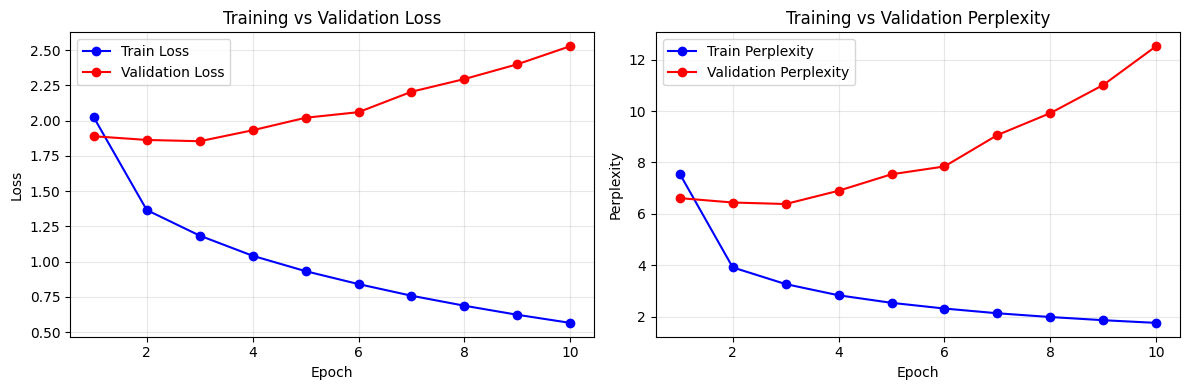

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, 'b-', label='Train Loss', marker='o')
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_perplexity, 'b-', label='Train Perplexity', marker='o')
ax2.plot(epochs, val_perplexity, 'r-', label='Validation Perplexity', marker='o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Perplexity')
ax2.set_title('Training vs Validation Perplexity')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Load Best Model

Load checkpoint terbaik (epoch 3, val_loss: 1.8538) untuk inference dan evaluasi.

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [20]:
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
feature_extractor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')

special_tokens = {
    'bos_token': '<|startoftext|>',
    'eos_token': '<|endoftext|>',
    'pad_token': '<|pad|>'
}
tokenizer.add_special_tokens(special_tokens)

2

In [21]:
checkpoint = torch.load('./vit_gpt2_rsic_checkpoint/vit_gpt2_rsic_best_model.pt', map_location=device)

model = ViTGPT2(
    vit_model='google/vit-base-patch16-224',
    gpt2_model='gpt2',
    num_image_tokens=49,
    freeze_vision=True,
    freeze_lm_initial_epochs=0,
    dropout=0.1,
    multi_scale_layers=[6, 9, 12]
)
model.gpt2.resize_token_embeddings(len(tokenizer))
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Val Loss: {checkpoint['val_loss']:.4f}")

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Loaded best model from epoch 3
Val Loss: 1.8538


## 11. Qualitative Evaluation — Sample Predictions

Visualisasi prediksi caption pada 5 sample gambar test set. Inference menggunakan **beam search** (num_beams=5) dengan repetition penalty (1.2) dan no-repeat ngram size (3).

In [17]:
def get_captions_for_image(df, img_path, path_col):
    matching_rows = df[df[path_col] == img_path]
    
    caption_col = None
    for col in ['caption', 'captions', 'text']:
        if col in df.columns:
            caption_col = col
            break
    
    if caption_col is None:
        return ['No caption found']
    
    captions = matching_rows[caption_col].tolist()
    
    cleaned = []
    for cap in captions:
        if isinstance(cap, str):
            cap = cap.strip().lower()
            cap = re.sub(r'\s+', ' ', cap)
            if cap:
                cleaned.append(cap)
        elif isinstance(cap, list):
            cleaned.extend([c.strip().lower() for c in cap if isinstance(c, str)])
    
    return cleaned if cleaned else ['No caption found']

In [18]:
def display_predictions(
    dataframe,
    model,
    tokenizer,
    feature_extractor,
    num_samples=5,
    seed=42,
    device='cuda',
    max_length=50,
    min_length=8,
    num_beams=5,
    repetition_penalty=1.2,
    no_repeat_ngram_size=3,
    figsize=(10, 8)
):
    if device == 'cuda' and not torch.cuda.is_available():
        device = 'cpu'
    
    model.eval()
    model.to(device)
    
    df = dataframe.reset_index(drop=True)
    
    path_col = None
    for col in ['image_path', 'filepath', 'path']:
        if col in df.columns:
            path_col = col
            break
    
    if path_col is None:
        print(f"ERROR: No image path column found! Columns: {df.columns.tolist()}")
        return
    
    unique_images = df[path_col].unique()
    
    np.random.seed(seed)
    sample_indices = np.random.choice(len(unique_images), min(num_samples, len(unique_images)), replace=False)
    sample_paths = unique_images[sample_indices]
    
    for i, img_path in enumerate(sample_paths, 1):
        print("-" * 110)
        print(f"Sample {i}/{num_samples}")
        
        try:
            pil_img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"ERROR loading image {img_path}: {e}")
            continue
        
        true_captions = get_captions_for_image(df, img_path, path_col)
        
        pixel_values = feature_extractor(pil_img, return_tensors='pt').pixel_values.to(device)
        
        with torch.no_grad():
            pred_caption = model.generate_caption(
                pixel_values=pixel_values,
                tokenizer=tokenizer,
                max_length=max_length,
                min_length=min_length,
                num_beams=num_beams,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                device=device
            )
        
        img_name = img_path.split('/')[-1]
        print(f"Image: {img_name}")
        fig, ax = plt.subplots(1, 1, figsize=figsize)
        ax.imshow(pil_img)
        ax.axis('off')
        
        plt.tight_layout()
        plt.show()
        plt.close()
        
        print(f"\nTrue Captions:")
        for j, cap in enumerate(true_captions[:5], 1):
            print(f"  {j}. {cap}")
        
        print(f"\nPredicted Caption: {pred_caption}")

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--------------------------------------------------------------------------------------------------------------
Sample 1/5
Image: mediumresidential_56.jpg


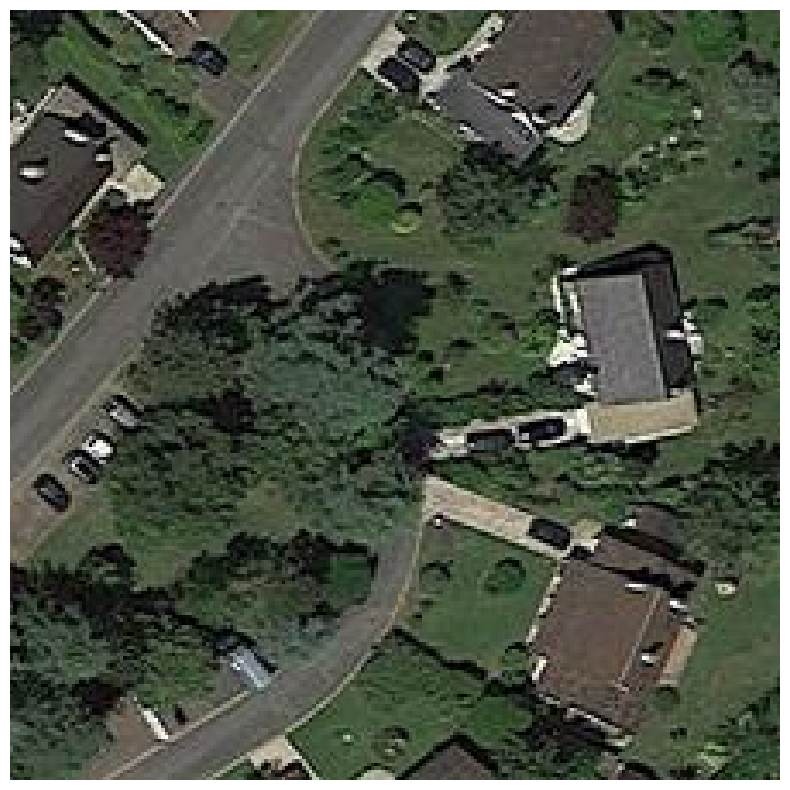


True Captions:
  1. on both sides of the road is a high quality residential area
  2. many trees were planted around the houses with grey roofs
  3. many green blocks are located in the midum residential area
  4. many green blocks are in the midum residential area
  5. on both sides of the road is a high-grade residential area

Predicted Caption: some buildings and many green trees are in a medium residential area.
--------------------------------------------------------------------------------------------------------------
Sample 2/5
Image: beach_61.jpg


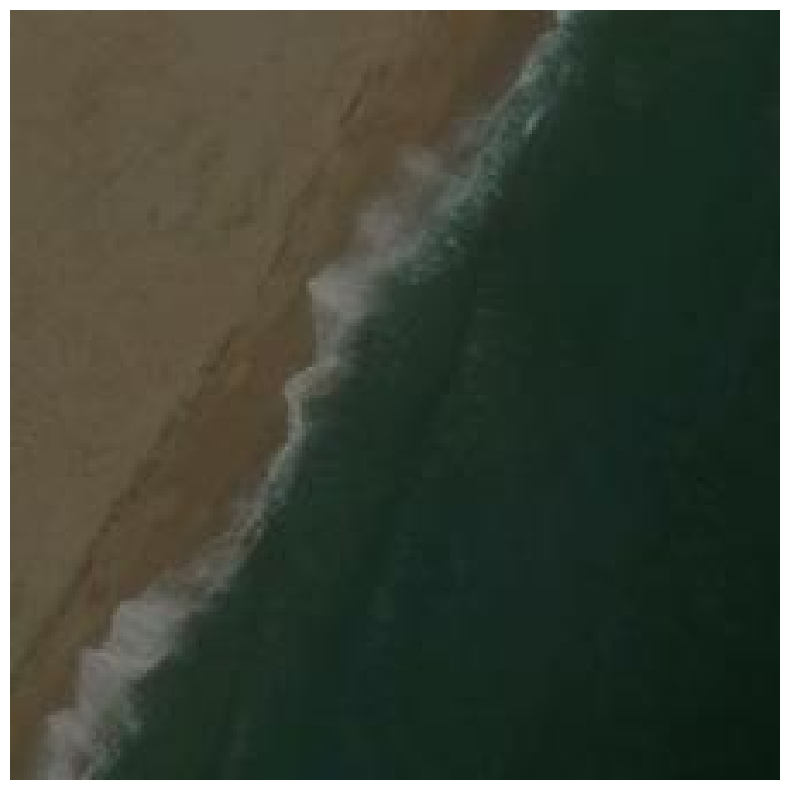


True Captions:
  1. in front of the sea is a vast beach.' 'the sea beats the wide beach
  2. the sea is beating the wide beach .' 'facing the sea is a wide beach
  3. in front of the sea is a vast beach

Predicted Caption: the sea beat the white spray on the beach.
--------------------------------------------------------------------------------------------------------------
Sample 3/5
Image: baseballfield_62.jpg


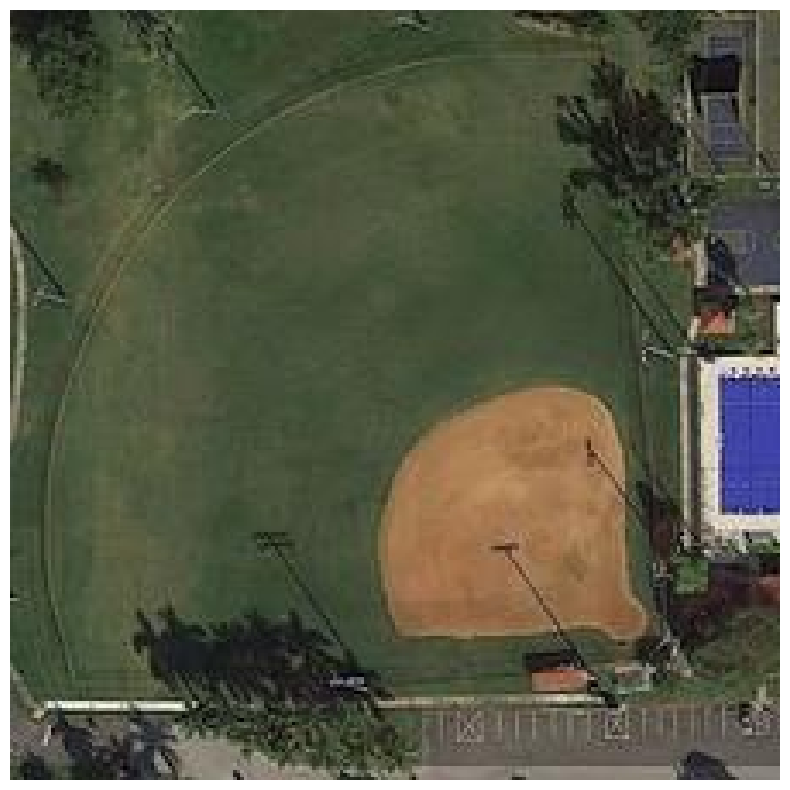


True Captions:
  1. the baseball field is next to a basketball field a volleyball court and a tennis court
  2. a parking lot is lying near the baseballfield next to which there are some other sports courts
  3. a fanshaped baseball field beside a basketball court and a tennis court
  4. a fan shaped baseballfield is surrounded by a basketball court several tennis courts and a parking lot
  5. several green trees are around a baseball field

Predicted Caption: two baseball fields are surrounded by green trees.
--------------------------------------------------------------------------------------------------------------
Sample 4/5
Image: school_58.jpg


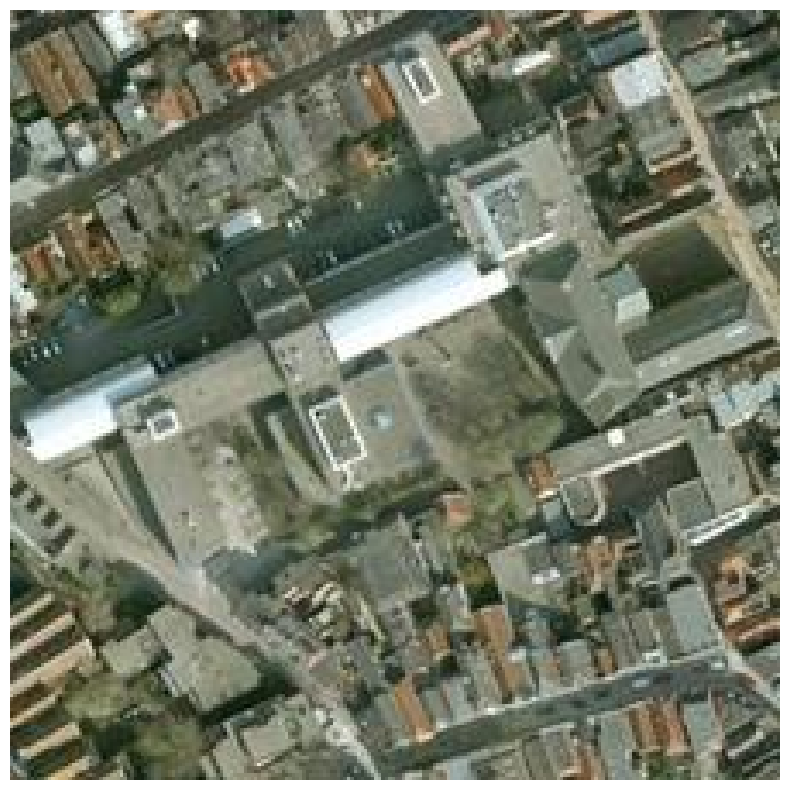


True Captions:
  1. the dense houses are close to each other
  2. the dense houses is close to each other
  3. a large teaching building lies in this school surrounded by dense residential houses
  4. many gray buildings and some trees are in a school

Predicted Caption: many buildings and some green trees are in a commercial area.
--------------------------------------------------------------------------------------------------------------
Sample 5/5
Image: railwaystation_56.jpg


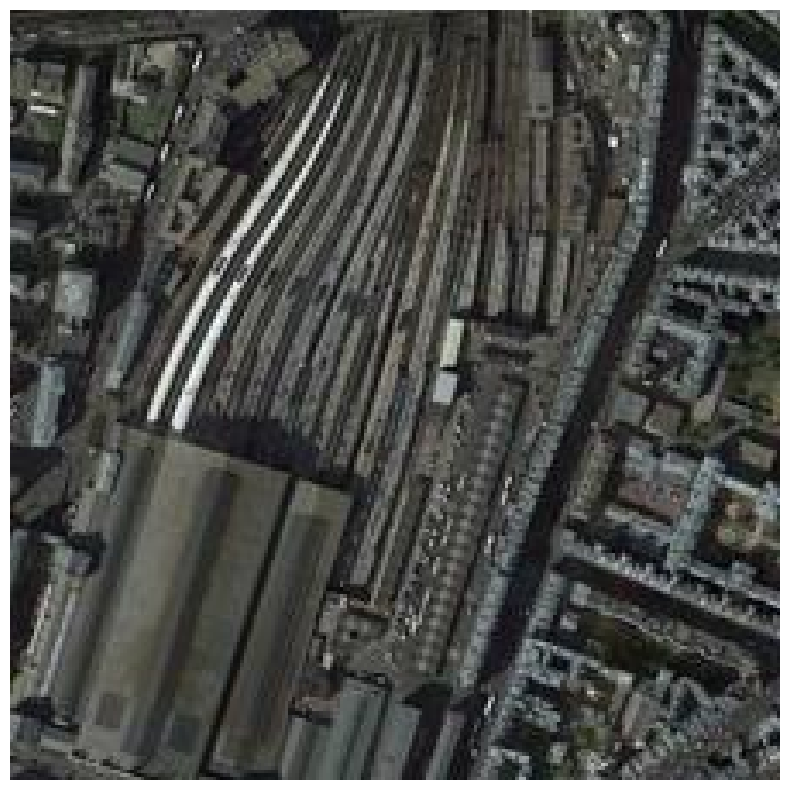


True Captions:
  1. the huge grey ceiling is above the rails
  2. the huge grey roof is on the rails
  3. the huge gray ceiling is over the rails
  4. two white trains are driving in this railway station next to a bustling road and buildings
  5. many gray buildings are in two sides of a railway station

Predicted Caption: many buildings are in two sides of a railway station.


In [22]:
display_predictions(
    dataframe=test_df,
    model=model,
    tokenizer=tokenizer,
    feature_extractor=feature_extractor,
    num_samples=5,
    seed=42,
    device='cuda'
)

## 12. Quantitative Evaluation — Metrics

Evaluasi kuantitatif pada seluruh test set (1.093 gambar unik) menggunakan standar metrics image captioning:
- **BLEU-1~4**: n-gram precision antara predicted dan reference captions
- **METEOR**: mengukur keselarasan semantik dengan stemming dan synonymy
- **ROUGE-L**: longest common subsequence antara predicted dan reference
- **CIDEr**: consensus-based metric yang memberi bobot pada kata-kata informatif

In [23]:
def generate_all_predictions(model, test_df, tokenizer, feature_extractor, device='cuda'):
    model.eval()
    
    unique_images = test_df['image_path'].unique()
    
    predictions = {}
    references = {}
    
    print(f"Generating captions for {len(unique_images)} images...")
    
    for idx, img_path in enumerate(tqdm(unique_images, desc='Generating')):
        try:
            image = Image.open(img_path).convert('RGB')
            pixel_values = feature_extractor(image, return_tensors='pt').pixel_values.to(device)
            
            with torch.no_grad():
                pred_caption = model.generate_caption(
                    pixel_values=pixel_values,
                    tokenizer=tokenizer,
                    max_length=50,
                    min_length=8,
                    num_beams=5,
                    repetition_penalty=1.2,
                    no_repeat_ngram_size=3,
                    device=device
                )
            
            true_captions = test_df[test_df['image_path'] == img_path]['caption'].tolist()
            true_captions = [cap.strip().lower() for cap in true_captions]
            
            predictions[idx] = [pred_caption.lower()]
            references[idx] = true_captions
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            continue
    
    return predictions, references

In [24]:
def compute_metrics(predictions, references):
    scorers = [
        (Bleu(4), ["BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4"]),
        (Meteor(), "METEOR"),
        (Rouge(), "ROUGE-L"),
        (Cider(), "CIDEr"),
    ]
    
    results = {}
    
    for scorer, method in scorers:
        try:
            score, scores = scorer.compute_score(references, predictions)
            
            if isinstance(method, list):
                for m, s in zip(method, score):
                    results[m] = s * 100
                    print(f"  {m}: {s * 100:.2f}")
            else:
                results[method] = score * 100
                print(f"  {method}: {score * 100:.2f}")
                
        except Exception as e:
            print(f"  Error computing {method}: {e}")
    
    return results

In [25]:
predictions, references = generate_all_predictions(
    model=model,
    test_df=test_df,
    tokenizer=tokenizer,
    feature_extractor=feature_extractor,
    device=device
)

results = compute_metrics(predictions, references)

Generating captions for 1093 images...


Generating: 100%|██████████| 1093/1093 [04:40<00:00,  3.90it/s]


{'testlen': 12035, 'reflen': 12028, 'guess': [12035, 10942, 9849, 8756], 'correct': [6697, 2940, 1552, 893]}
ratio: 1.0005819753906717
  BLEU-1: 55.65
  BLEU-2: 38.67
  BLEU-3: 28.67
  BLEU-4: 22.14
  METEOR: 25.46
  ROUGE-L: 40.90
  CIDEr: 37.53


## 13. Results Summary

Hasil evaluasi akhir model **ViT-GPT2** pada test set:

| Metric | Score |
|--------|-------|
| BLEU-1 | 55.65 |
| BLEU-2 | 38.67 |
| BLEU-3 | 28.67 |
| BLEU-4 | 22.14 |
| METEOR | 25.46 |
| ROUGE-L | 40.90 |
| CIDEr | 37.53 |

> Meskipun menggunakan arsitektur yang lebih kompleks (multi-scale features + spatial attention), ViT-GPT2 menunjukkan performa di bawah RemoteCLIP-GPT2 pada hampir semua metrik. Hal ini mengindikasikan bahwa **kualitas representasi visual domain-specific** (RemoteCLIP) lebih berpengaruh dibanding kompleksitas arsitektur projector dalam task RSIC.